# Setup

In [20]:
!pip install scikit-image
!pip install opencv-python

In [21]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os
import warnings

from google.colab.patches import cv2_imshow

warnings.filterwarnings("ignore")

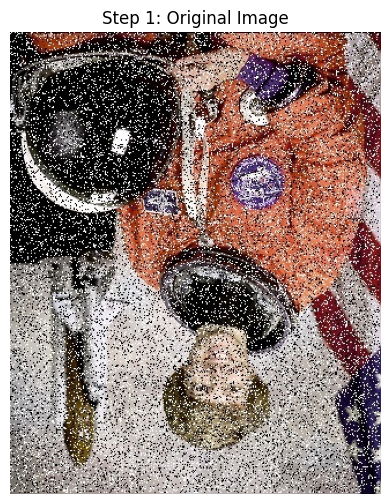

In [23]:
# Read file
# 讀取影像 (請確認 ex4.jpg 在正確路徑)
img = cv2.imread('ex4.jpg')

# 將 BGR 轉為 RGB 以利 matplotlib 顯示
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 6))
plt.title("Step 1: Original Image")
plt.imshow(img_rgb)
plt.axis('off')
plt.show()

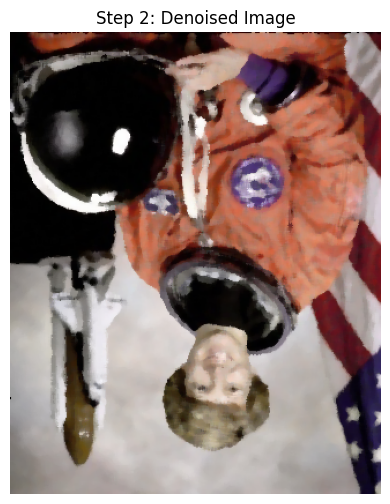

In [24]:
# Denoise by filter
# 中值濾波去雜訊
img_denoised = cv2.medianBlur(img, 5)

img_denoised_rgb = cv2.cvtColor(img_denoised, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(6, 6))
plt.title("Step 2: Denoised Image")
plt.imshow(img_denoised_rgb)
plt.axis('off')
plt.show()

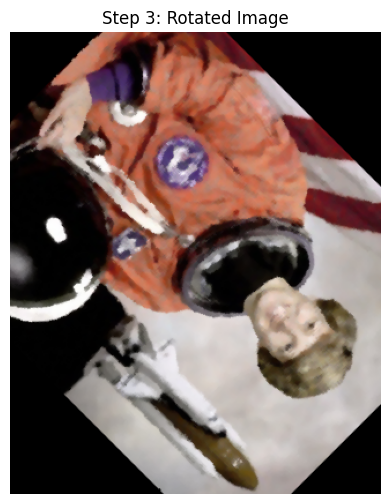

In [25]:
# Rotate
# 取得影像長寬
h, w = img_denoised.shape[:2]
center = (w // 2, h // 2)

# 取得旋轉矩陣 (中心點, 角度45, 縮放比例1.0)
M = cv2.getRotationMatrix2D(center, 45, 1.0)
img_rotated = cv2.warpAffine(img_denoised, M, (w, h))

img_rotated_rgb = cv2.cvtColor(img_rotated, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(6, 6))
plt.title("Step 3: Rotated Image")
plt.imshow(img_rotated_rgb)
plt.axis('off')
plt.show()

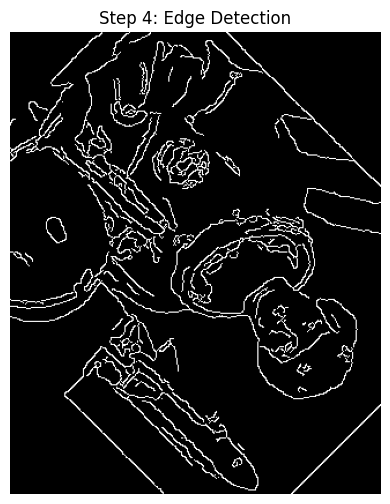

In [26]:
# Edge Detection
# 先轉換為灰階
img_gray = cv2.cvtColor(img_rotated, cv2.COLOR_BGR2GRAY)

# Canny 邊緣偵測
edges = cv2.Canny(img_gray, 100, 200)

plt.figure(figsize=(6, 6))
plt.title("Step 4: Edge Detection")
plt.imshow(edges, cmap='gray')
plt.axis('off')
plt.show()

In [27]:
# save image
# 儲存影像 (請將檔名修改為您的 學號_姓名)
save_filename = '113034038_林彥妤.jpg'
cv2.imwrite(save_filename, edges)

print(f"影像儲存成功：{save_filename}")

影像儲存成功：113034038_林彥妤.jpg


# Image Registration (Bonus)

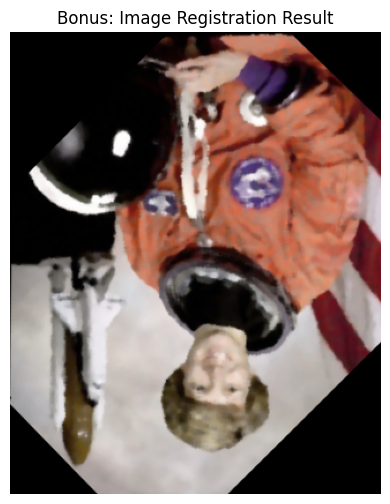

In [33]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- 步驟 0：確保兩張圖都轉成灰階，以利特徵萃取 ---
img_orig_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_rotated_gray = cv2.cvtColor(img_rotated, cv2.COLOR_BGR2GRAY)

# --- 步驟 1：萃取特徵點 ---
# 建立 ORB 偵測器 (設定最多找 5000 個特徵點)
orb = cv2.ORB_create(5000)

# 分別找出原圖 (kp1) 與 旋轉圖 (kp2) 的關鍵點與描述子
kp1, des1 = orb.detectAndCompute(img_orig_gray, None)
kp2, des2 = orb.detectAndCompute(img_rotated_gray, None)

# --- 步驟 2：特徵匹配 ---
# 使用暴力匹配法 (Brute-Force Matcher) 來配對特徵
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches = bf.match(des1, des2)

# 按照匹配的誤差距離排序，並只保留前 15% 最精準的配對點
matches = sorted(matches, key=lambda x: x.distance)
good_matches = matches[:int(len(matches) * 0.15)]

# --- 步驟 3：計算轉換矩陣 (Homography) ---
# 取出這些精準配對點的 X, Y 座標
src_pts = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
dst_pts = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

# 計算單應性矩陣 H (使用 RANSAC 演算法過濾掉極端的錯誤配對)
H, mask = cv2.findHomography(dst_pts, src_pts, cv2.RANSAC, 5.0)

# --- 步驟 4：影像變換 (轉正) ---
# 取得原本圖片的長寬
h, w = img_orig_gray.shape

# 套用矩陣 H，把旋轉圖 img_rotated 轉換回原圖視角
img_registered = cv2.warpPerspective(img_rotated, H, (w, h))

# --- 顯示結果 ---
# 將 BGR 轉回 RGB 以供畫圖顯示
img_registered_rgb = cv2.cvtColor(img_registered, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 6))
plt.title("Bonus: Image Registration Result")
plt.imshow(img_registered_rgb)
plt.axis('off')
plt.show()

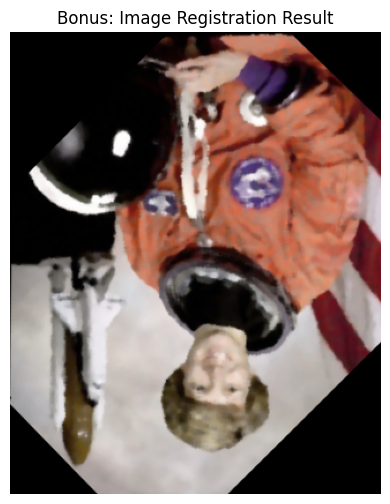

In [34]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- 步驟 0：確保兩張圖都轉成灰階，以利特徵萃取 ---
img_orig_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_rotated_gray = cv2.cvtColor(img_rotated, cv2.COLOR_BGR2GRAY)

# --- 步驟 1：萃取特徵點 ---
# 建立 ORB 偵測器 (設定最多找 5000 個特徵點)
orb = cv2.ORB_create(5000)

# 分別找出原圖 (kp1) 與 旋轉圖 (kp2) 的關鍵點與描述子
kp1, des1 = orb.detectAndCompute(img_orig_gray, None)
kp2, des2 = orb.detectAndCompute(img_rotated_gray, None)

# --- 步驟 2：特徵匹配 ---
# 使用暴力匹配法 (Brute-Force Matcher) 來配對特徵
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches = bf.match(des1, des2)

# 按照匹配的誤差距離排序，並只保留前 15% 最精準的配對點
matches = sorted(matches, key=lambda x: x.distance)
good_matches = matches[:int(len(matches) * 0.15)]

# --- 步驟 3：計算轉換矩陣 (Homography) ---
# 取出這些精準配對點的 X, Y 座標
src_pts = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
dst_pts = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

# 計算單應性矩陣 H (使用 RANSAC 演算法過濾掉極端的錯誤配對)
H, mask = cv2.findHomography(dst_pts, src_pts, cv2.RANSAC, 5.0)

# --- 步驟 4：影像變換 (轉正) ---
# 取得原本圖片的長寬
h, w = img_orig_gray.shape

# 套用矩陣 H，把旋轉圖 img_rotated 轉換回原圖視角
img_registered = cv2.warpPerspective(img_rotated, H, (w, h))

# --- 顯示結果 ---
# 將 BGR 轉回 RGB 以供畫圖顯示
img_registered_rgb = cv2.cvtColor(img_registered, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 6))
plt.title("Bonus: Image Registration Result")
plt.imshow(img_registered_rgb)
plt.axis('off')
plt.show()